<a href="https://colab.research.google.com/github/leesasang/codein_study/blob/main/%EC%9D%B4%EC%B1%84%EC%97%B0_%EA%B0%9C%EC%9D%B8%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

In [2]:
zip_path = "/content/I-V_curves_raw_data.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/iv_data")

In [3]:
os.listdir("/content/iv_data")

['I-V_375Wm-2.txt',
 'I-V_875Wm-2.txt',
 'I-V_1500Wm-2.txt',
 'I-V_1250Wm-2.txt',
 'I-V_1000Wm-2.txt',
 'I-V_500Wm-2.txt',
 'I-V_1125Wm-2.txt',
 'I-V_625Wm-2.txt',
 'I-V_750Wm-2.txt',
 'I-V_250Wm-2.txt',
 'I-V_1375Wm-2.txt']

In [4]:
for root, dirs, files in os.walk("/content/iv_data"):
    print("폴더:", root)
    print("파일:", files[:5])

폴더: /content/iv_data
파일: ['I-V_375Wm-2.txt', 'I-V_875Wm-2.txt', 'I-V_1500Wm-2.txt', 'I-V_1250Wm-2.txt', 'I-V_1000Wm-2.txt']


In [6]:
sample_file = "/content/iv_data/I-V_375Wm-2.txt"

df = pd.read_csv(
    sample_file,
    delim_whitespace=True,
    header=None
)

df.head()

/tmp/ipykernel_15452/1404877446.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


,0,1,2,3,4,5
0,V,/,V,I,/,A
1,-12.85564615,3.638949169,NaN,NaN,NaN,NaN
2,-12.67367887,3.638949169,NaN,NaN,NaN,NaN
3,-12.46138371,3.681427175,NaN,NaN,NaN,NaN
4,-12.26425249,3.638949169,NaN,NaN,NaN,NaN


In [8]:
sample_file = "/content/iv_data/I-V_375Wm-2.txt"

df = pd.read_csv(
    sample_file,
    sep='\t',
    skiprows=1,
    names=['V', 'I']
)

df.head()

,V,I
0,-12.855646,3.638949
1,-12.673679,3.638949
2,-12.461384,3.681427
3,-12.264252,3.638949
4,-12.036793,3.653109


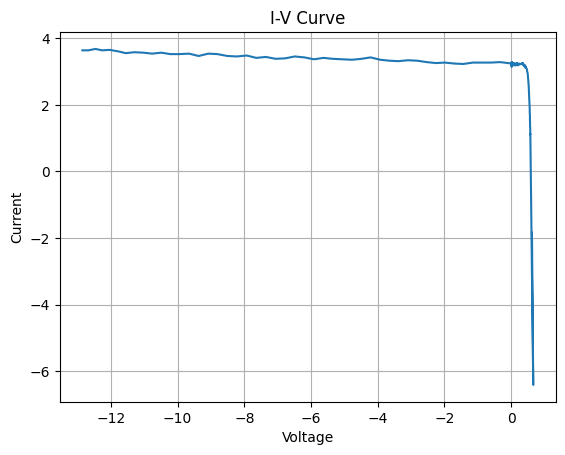

In [9]:
plt.plot(df['V'], df['I'])

plt.xlabel("Voltage")
plt.ylabel("Current")

plt.title("I-V Curve")

plt.grid()

plt.show()

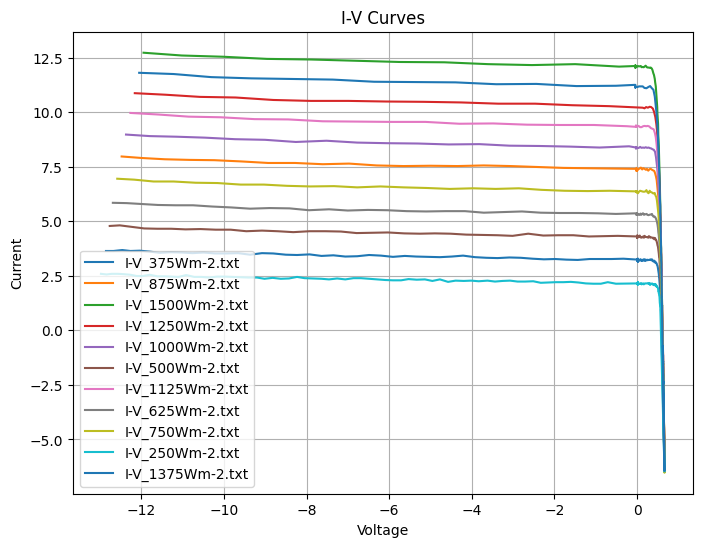

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt

folder = "/content/iv_data"

plt.figure(figsize=(8,6))

for file in os.listdir(folder):

    if file.endswith(".txt"):

        path = os.path.join(folder, file)

        df = pd.read_csv(
            path,
            sep='\t',
            skiprows=1,
            names=['V','I']
        )

        plt.plot(df['V'], df['I'], label=file)

plt.xlabel("Voltage")
plt.ylabel("Current")

plt.title("I-V Curves")

plt.legend()
plt.grid()

plt.show()

In [11]:
import pandas as pd
import numpy as np

# 정상 데이터 불러오기
df = pd.read_csv(
    "/content/iv_data/I-V_375Wm-2.txt",
    sep='\t',
    skiprows=1,
    names=['V','I']
)

# 1. 정상 데이터 저장

df.to_csv("normal.csv", index=False)

# 2. 노이즈 추가

noise_df = df.copy()

noise_df['I'] = (
    noise_df['I']
    + np.random.normal(0, 0.2, len(noise_df))
)

noise_df.to_csv("noisy_fault.csv", index=False)

# 3. 성능 저하

degraded_df = df.copy()

degraded_df['I'] = degraded_df['I'] * 0.7

degraded_df.to_csv("degraded_fault.csv", index=False)

print("파일 생성 완료")

파일 생성 완료


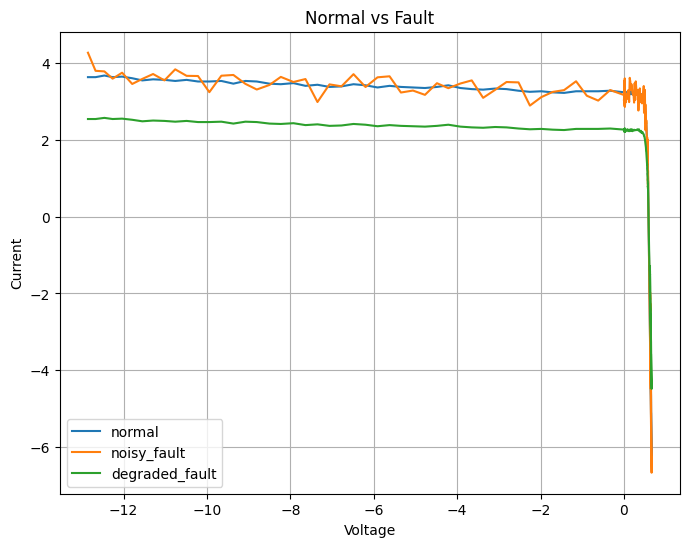

In [12]:
plt.figure(figsize=(8,6))

plt.plot(df['V'], df['I'], label='normal')

plt.plot(
    noise_df['V'],
    noise_df['I'],
    label='noisy_fault'
)

plt.plot(
    degraded_df['V'],
    degraded_df['I'],
    label='degraded_fault'
)

plt.xlabel("Voltage")
plt.ylabel("Current")

plt.title("Normal vs Fault")

plt.legend()
plt.grid()

plt.show()